# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [4]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

fish: Unknown command: pip
fish: 
pip -q install pandas requests flask matplotlib
^~^
Environment ready.


In [ ]:
# 1. LOAD THE CLASSROOM PACK
# In Colab, upload FlashEats_Classroom_Pack.zip when prompted.

BASE = Path(".2")

if not BASE.exists():
    try:
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")
    except Exception as e:
        print("If running locally, set BASE manually to the extracted pack.")
        print(e)

print("BASE:", BASE)
print("Exists:", BASE.exists())

BASE: .
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders` table | It's set at checkout and stored centrally. |
| Actual delivery time | `orders` table | Final delivery state should be recorded here. |
| Driver assignment | `driver_events.json` | Driver assignment events capture real-time dispatch. |
| Customer complaint | `support_tickets.csv` | Represents the human-in-the-loop CS system. |
| Restaurant status | `restaurant_status.csv` | Explicit signals (like 'food_ready') from the kitchen. |
| Driver movement/events | `driver_events.json` | Holds raw GPS pings and status updates from the app. |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?
Source systems like the driver app are authoritative for their state, but events might be delayed or inferred.

In [6]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,None,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** `actual_delivery_at` > `promised_eta`
- **Denominator:** Total number of delivered orders
- **Cancelled orders:** exclude
- **Missing actual delivery timestamp:** exclude from lateness calculations
- **Row grain:** One order per row in the `orders` table.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [7]:
query = """
SELECT COUNT(*) as valid_delivered_orders,
       SUM(CASE WHEN datetime(actual_delivery_at) > datetime(promised_eta) THEN 1 ELSE 0 END) as late_orders,
       SUM(CASE WHEN datetime(actual_delivery_at) > datetime(promised_eta) THEN 1 ELSE 0 END) * 1.0 / COUNT(*) as late_rate
FROM orders
WHERE final_status = 'delivered'
  AND actual_delivery_at IS NOT NULL
  AND promised_eta IS NOT NULL;
"""
orders_preview = pd.read_sql(query, con)
display(orders_preview)

# Calculating median lateness and worst delayed orders
orders = pd.read_sql("SELECT * FROM orders WHERE final_status = 'delivered' AND actual_delivery_at IS NOT NULL AND promised_eta IS NOT NULL;", con)
orders["promised_eta"] = pd.to_datetime(orders["promised_eta"], format="mixed", errors="coerce")
orders["actual_delivery_at"] = pd.to_datetime(orders["actual_delivery_at"], format="mixed", errors="coerce")
orders["delay_min"] = (orders["actual_delivery_at"] - orders["promised_eta"]).dt.total_seconds() / 60

late_orders = orders[orders["delay_min"] > 0]
print("Median Lateness (mins):", late_orders["delay_min"].median())
print("Worst Delayed Orders:")
display(late_orders.sort_values("delay_min", ascending=False)[['order_id', 'delay_min']].head(5))


,valid_delivered_orders,late_orders,late_rate
0,1493,841,0.563295


Median Lateness (mins): 8.012327516666666
Worst Delayed Orders:


,order_id,delay_min
98,O00104,87.345669
96,O00102,86.294363
95,O00101,85.511421
97,O00103,69.289038
1006,O01081,50.267747


## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

,count,median,mean
traffic_bucket,,,
HIGH,2,13.888096,13.888096
high,422,3.991626,5.235176
low,357,-0.153575,1.061664
medium,589,0.214061,2.096121
severe,123,4.263769,6.316358


,count,median,mean
weather_bucket,,,
clear,1191,0.766871,2.185951
heavy_rain,72,6.629961,7.745551
rain,230,4.248023,6.375717


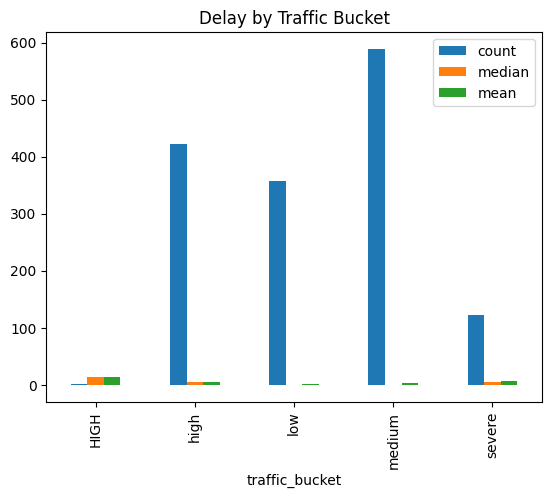


Hypothesis: High traffic contributes to longer delays, as seen by higher mean/median delays in severe/high buckets.
Alternative explanation: We cannot rule out that severe traffic also affects restaurant prep time (e.g. staff arrives late), so traffic might be associated but not solely the direct cause of driver delay.


In [8]:
summary = orders.groupby("traffic_bucket")["delay_min"].agg(["count","median","mean"])
display(summary)
summary2 = orders.groupby("weather_bucket")["delay_min"].agg(["count","median","mean"])
display(summary2)

summary.plot(kind="bar")
plt.title("Delay by Traffic Bucket")
plt.show()

print("\nHypothesis: High traffic contributes to longer delays, as seen by higher mean/median delays in severe/high buckets.")
print("Alternative explanation: We cannot rule out that severe traffic also affects restaurant prep time (e.g. staff arrives late), so traffic might be associated but not solely the direct cause of driver delay.")


# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [9]:
display(tickets.head())

print("Complaint categories:")
tickets['category_cleaned'] = tickets['category'].str.strip().str.lower().str.replace(' ', '_')
display(tickets["category_cleaned"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())

print("\n1. Customers complain mostly about late deliveries, eta changes, and restaurant delays.")
print("2. `late_delivery`, `eta_changed`, `restaurant_delay` are most common.")
print("3. Are ticket IDs unique? Mostly yes, but there is 1 duplicate.")
print("4. Customer story vs Operational story: Support tickets explicitly mention restaurant delays and ETA changes, suggesting the ETA algorithm itself is confusing customers or failing to account for restaurant wait times, which goes beyond just traffic.")
print("5. Tickets tell us the user's perception (e.g. app says 'ready but waiting' or 'driver not moving'), which timestamps alone don't capture.")


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category_cleaned
late_delivery        40
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
eta_issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1

1. Customers complain mostly about late deliveries, eta changes, and restaurant delays.
2. `late_delivery`, `eta_changed`, `restaurant_delay` are most common.
3. Are ticket IDs unique? Mostly yes, but there is 1 duplicate.
4. Customer story vs Operational story: Support tickets explicitly mention restaurant delays and ETA changes, suggesting the ETA algorithm itself is confusing customers or failing to account for restaurant wait times, which goes beyond just traffic.
5. Tickets tell us the user's perception (e.g. app says 'ready but waiting' or 'driver not moving'), which timestamps alone don't capture.


# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [10]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [11]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [12]:
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders():
    records = []
    page = 1
    while True:
        try:
            response = requests.get(API_URL, params={"page": page, "page_size": 50}, timeout=10)
            if response.status_code in [429, 500]:
                time.sleep(1)
                continue
            response.raise_for_status()
            payload = response.json()
            
            with open(RAW_DIR / f'page_{page}.json', 'w') as f:
                json.dump(payload, f)
                
            records.extend(payload["data"])
            if not payload.get("has_more"):
                break
            page += 1
        except requests.RequestException as e:
            print(f'Error fetching page {page}: {e}')
            time.sleep(1)
    return records

dispatch_records = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records))


Retrieved: 1600


# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**
No, we only have inferred GPS pings and the manual `picked_up` event. There is no explicit `driver_arrived` event recorded.

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | `driver_events` | System generated, highly reliable |
| Driver at restaurant | Inferred | GPS pings / `driver_events` | Relies on proximity heuristics, easily disrupted by GPS drift |
| Picked up | Observed | `driver_events` | Manually triggered by driver; they may forget or press it late |
| Delivered | Observed | `driver_events` | Manually triggered, subject to driver behavior |

In [13]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# TODO: can you find an explicit driver_arrived_at_restaurant event?

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — The data shows a late-delivery rate of ~56% among delivered orders.
2. **Evidence** — Traffic is associated with higher median delays, but high delay rates persist even in low-traffic conditions. Support tickets point heavily towards restaurant delays and ETA changes.
3. **Trusted sources** — We trust the `orders` table for end-to-end times, and support tickets for customer sentiment. We do not fully trust the `driver_events` for pinpointing restaurant arrival due to missing explicit events.
4. **Uncertainty** — We cannot confidently determine whether drivers are waiting at the restaurant or if they are taking too long to arrive, because we lack a true `driver_arrived_at_restaurant` timestamp.
5. **Instrumentation recommendation** — FlashEats should capture/fix next the explicit timestamps for when the driver arrives at the restaurant and when the food is physically ready.
6. **Decision** — We should NOT build the AI delay predictor now. We would need the aforementioned explicit granular event data before concluding an ML model can accurately predict the true bottleneck.

In [14]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
